**Students:** Ivana Petrovic, Noel Fraser
**Section:** A
**Date:** May 3, 2026
**Responsibilities:** We shared the work and both presented.

In [3]:
import pandas as pd, matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('mdc_restaurant_inspections_2025.csv')
print(df.shape)

(5309, 8)


In [1]:
df.isna().sum()

zip_code 0
inspection_date 0
cuisine 15
score 54
dtype: int64

There are 54 missing scores. We dropped them.

In [4]:
df = df.dropna(subset=['score'])
df['inspection_date'] = pd.to_datetime(df['inspection_date'])
df = df.drop_duplicates(subset='inspection_id')
print(len(df))

5230


Dates are converted and duplicates are removed, leaving 5,230 inspections. (zip_code is still a number.)

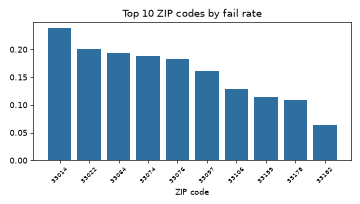

In [5]:
fail_rate = df.assign(fail=df['result'] == 'Fail').groupby('zip_code')['fail'].mean()
top10 = fail_rate.sort_values(ascending=False).head(10)
top10.plot(kind='bar')
plt.show()

ZIP code 33014 have the most high fail rate (23.8%). The other ZIP codes are lower.

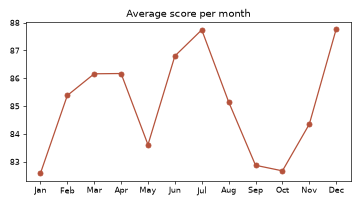

In [6]:
monthly = df.groupby(df['inspection_date'].dt.month)['score'].mean()
monthly.plot(marker='o')
plt.show()

The average score is highest in Dec and lowest in Jan.

In [7]:
per = df.groupby('cuisine')['violations'].mean().sort_values(ascending=False)
per.head(4)

cuisine   violations_per_inspection
Seafood   4.49
Italian   4.48
Chinese   1.94
Steakhouse1.83

Seafood has the most violations per inspection (4.49), and Steakhouse the fewest (1.83).